# Simple Newton Method for Equality Constrained NLPs

**Reference**: Section 5.2 in Biegler (2010)

![Alg51](https://raw.githubusercontent.com/ndcbe/optimization/main/media/alg5-1.png)

## Helper Functions


In [1]:
# Load required Python libraries.
import matplotlib.pyplot as plt
import numpy as np
from scipy import linalg


## Check if element of array is NaN
def check_nan(A):
    return np.sum(np.isnan(A))


## Calculate gradient with central finite difference
def my_grad_approx(x, f, eps1, verbose=False):
    """
    Calculate gradient of function f using central difference formula

    Inputs:
        x - point for which to evaluate gradient
        f - function to consider
        eps1 - perturbation size

    Outputs:
        grad - gradient (vector)
    """

    n = len(x)
    grad = np.zeros(n)

    if verbose:
        print("***** my_grad_approx at x = ", x, "*****")

    for i in range(0, n):

        # Create vector of zeros except eps in position i
        e = np.zeros(n)
        e[i] = eps1

        # Finite difference formula
        my_f_plus = f(x + e)
        my_f_minus = f(x - e)

        # Diagnostics
        if verbose:
            print("e[", i, "] = ", e)
            print("f(x + e[", i, "]) = ", my_f_plus)
            print("f(x - e[", i, "]) = ", my_f_minus)

        grad[i] = (my_f_plus - my_f_minus) / (2 * eps1)

    if verbose:
        print("***** Done. ***** \n")

    return grad


def my_jac_approx(x, h, eps1, verbose=False):
    """
    Calculate Jacobian of function h(x) using central difference formula

    Inputs:
        x - point for which to evaluate gradient
        h - vector-valued function to consider. h(x): R^n --> R^m
        eps1 - perturbation size

    Outputs:
        A - Jacobian (n x m matrix)
    """

    # Check h(x) at x
    h_x0 = h(x)

    # Extract dimensions
    n = len(x)
    m = len(h_x0)

    # Initialize Jacobian matrix
    A = np.zeros((n, m))

    # Calculate Jacobian by row
    for i in range(0, n):

        # Create vector of zeros except eps in position i
        e = np.zeros(n)
        e[i] = eps1

        # Finite difference formula
        my_h_plus = h(x + e)
        my_h_minus = h(x - e)

        # Diagnostics
        if verbose:
            print("e[", i, "] = ", e)
            print("h(x + e[", i, "]) = ", my_h_plus)
            print("h(x - e[", i, "]) = ", my_h_minus)

        A[i, :] = (my_h_plus - my_h_minus) / (2 * eps1)

    if verbose:
        print("***** Done. ***** \n")

    return A


## Calculate gradient using central finite difference and my_hes_approx
def my_hes_approx(x, grad, eps2):
    """
    Calculate gradient of function my_f using central difference formula and my_grad

    Inputs:
        x - point for which to evaluate gradient
        grad - function to calculate the gradient
        eps2 - perturbation size (for Hessian NOT gradient approximation)

    Outputs:
        H - Hessian (matrix)
    """

    n = len(x)
    H = np.zeros([n, n])

    for i in range(0, n):
        # Create vector of zeros except eps in position i
        e = np.zeros(n)
        e[i] = eps2

        # Evaluate gradient twice
        grad_plus = grad(x + e)
        grad_minus = grad(x - e)

        # Notice we are building the Hessian by column (or row)
        H[:, i] = (grad_plus - grad_minus) / (2 * eps2)

    return H


## Linear algebra calculation
def xxT(u):
    """
    Calculates u*u.T to circumvent limitation with SciPy

    Arguments:
    u - numpy 1D array

    Returns:
    u*u.T

    Assume u is a nx1 vector.
    Recall: NumPy does not distinguish between row or column vectors

    u.dot(u) returns a scalar. This function returns an nxn matrix.
    """

    n = len(u)
    A = np.zeros([n, n])
    for i in range(0, n):
        for j in range(0, n):
            A[i, j] = u[i] * u[j]

    return A


## Analyze Hessian
def analyze_hes(B):
    print(B, "\n")

    l = linalg.eigvals(B)
    print("Eigenvalues: ", l, "\n")

## Algorithm 5.1

In [2]:
def alg51(x0, calc_f, calc_h, eps1=1e-6, eps2=1e-6, max_iter=50, verbose=False):
    """
    Basic Full Space Newton Method for Equality Constrained NLP

    Input:
        x0 - starting point (vector)
        calc_f - function to calculate objective (returns scalar)
        calc_h - function to calculate constraints (returns vector)
        eps1 - tolerance for primal and dual steps
        eps2 - tolerance for gradient of L1

    Outputs:
        x - history of steps (primal variables)
        v - history of steps (dual variables)
        f - history of objective evaluations
        h - history of constraint evaluations
        df - history of objective gradients
        dL - history of Lagrange function gradients
        A - history of constraint Jacobians
        W - history of Lagrange Hessians

    Notes:
        1. For simplicity, central finite difference is used
           for all gradient calculations.
    """

    # Declare iteration histories as empty lists
    x = []
    v = []
    f = []
    L = []
    h = []
    df = []
    dL = []
    A = []
    W = []

    # Flag for iterations
    flag = True

    # Iteration counter
    k = 0

    # Copy initial point to primal variable history
    n = len(x0)
    x.append(x0)

    # Evaluate objective and constraints at initial point
    f.append(calc_f(x0))
    h.append(calc_h(x0))

    # Determine number of equality constraints
    m = len(h[0])

    # Initial dual variables with vector of ones
    v.append(np.ones(m))

    # Print header for iteration information
    print("Iter. \tf(x) \t\t||h(x)|| \t||grad_L(x)|| \t||dx|| \t\t||dv||")

    while flag and k < max_iter:

        # STEP 1. Construct KKT matrix

        if k > 0:
            # Evaluate objective function
            f.append(calc_f(x[k]))

            # Evaluate constraint function
            h.append(calc_h(x[k]))

        # Evaluate objective gradient
        df.append(my_grad_approx(x[k], calc_f, 1e-6))

        # Evaluate constraint Jacobian
        A.append(my_jac_approx(x[k], calc_h, 1e-6))

        # Evaluate gradient of Lagrange function
        L_func = lambda x_: calc_f(x_) + (calc_h(x_)).dot(v[k])
        L_grad = lambda x_: my_grad_approx(x_, L_func, 1e-6)
        dL.append(L_grad(x[k]))
        norm_dL = linalg.norm(dL[k])

        # Evaluate Hessian of Lagrange function
        W.append(my_hes_approx(x[k], L_grad, 1e-6))

        if verbose:
            print("*** k =", k, " ***")
            print("x_k =", x[k])
            print("v_k =", v[k])
            print("f_k =", f[k])
            print("df_k =", df[k])
            print("h_k =", h[k])
            print("A_k =\n", A[k])
            print("W_k =\n", W[k])
            print("\n")

        # Assemble KKT matrix
        KKT_top = np.concatenate((W[k], A[k]), axis=1)
        KKT_bot = np.concatenate((A[k].T, np.zeros((m, m))), axis=1)
        KKT = np.concatenate((KKT_top, KKT_bot), axis=0)

        if verbose:
            print("KKT matrix =\n", KKT, "\n")

        # Check if KKT matrix is singular
        l, eigvec = linalg.eig(KKT)

        if verbose:
            print("KKT matrix eigenvalues:")
            print(l)

        zero_eigenvalues = sum(np.abs(l) <= 1e-8)

        if zero_eigenvalues > 0:
            flag = False
            print("KKT matrix is singular. Eigenvalues:\n")
            print(l, "\n")

        ## STEP 2. Solve linear system.

        if flag:
            b = -np.concatenate((dL[k], h[k]), axis=0)
            z = linalg.solve(KKT, b)
        else:
            z = []

        ## STEP 3. Take step
        if flag:
            dx = z[0:n]
            dv = z[n : n + m]

            x.append(x[k] + dx)
            v.append(v[k] + dv)

            norm_dx = linalg.norm(dx)
            norm_dv = linalg.norm(dv)

        ## Print iteration information
        print(
            k,
            "  \t{0: 1.4e} \t{1:1.4e} \t{2:1.4e}".format(
                f[k], linalg.norm(h[k]), norm_dL
            ),
            end="",
        )

        if flag:
            print(" \t{0: 1.4e} \t{1: 1.4e}".format(norm_dx, norm_dv), end="\n")
        else:
            print(" \t -------  \t -------", end="\n")

        # Increment counter
        k = k + 1

        ## Check convergence criteria
        if flag:
            flag = norm_dx > eps1 and norm_dv > eps1 and norm_dL > eps2

    if flag and k >= max_iter:
        print("Reached maximum number of iterations.")

    return x, v, f, h, df, dL, A, W

## Example Problem 1

Consider:

$$\begin{align*} \min_{x} \quad & x_1^2 + 2 x_2^2 - x_3 \\
\mathrm{s.t.} \quad & x_1 + x_2 = 1 \\
& x_1 + x_2 - x_3 = 5
\end{align*} $$

### Define Functions

In [3]:
def my_f(x):
    return x[0] ** 2 + 2 * x[1] ** 2 - 1 * x[2]


def my_h(x):
    h = np.zeros(2)

    h[0] = x[0] + x[1] - 1
    h[1] = x[0] + x[1] - x[2] - 5

    return h

### Test Finite Difference Approximations

In [4]:
## Define initial point
x0 = np.array([1, 1, 1])

## Calculate objective
print("f(x0) =", my_f(x0), "\n")

## Calculate constraints
print("h(x0) =", my_h(x0), "\n")

## Calculate objective gradient
print("df(x0) =", my_grad_approx(x0, my_f, 1e-6), "\n")

## Calculate constraint Jacobian
print("dh(x0) =\n", my_jac_approx(x0, my_h, 1e-6), "\n")

f(x0) = 2 

h(x0) = [ 1. -4.] 

df(x0) = [ 2.  4. -1.] 

dh(x0) =
 [[ 1.  1.]
 [ 1.  1.]
 [ 0. -1.]] 



### Test Algorithm 5.1

In [5]:
## Run Algorithm 5.1 on test problem
results = alg51(x0, my_f, my_h)

## Display results
xstar = results[0][-1]
print("\nx* =", xstar)

## Display results
vstar = results[1][-1]
print("\nv* =", vstar)

Iter. 	f(x) 		||h(x)|| 	||grad_L(x)|| 	||dx|| 		||dv||
0   	 2.0000e+00 	4.1231e+00 	7.4833e+00 	 5.0553e+00 	 2.4040e+00
1   	 4.6667e+00 	5.7632e-10 	8.2956e-04 	 1.4999e-04 	 6.2902e-04
2   	 4.6667e+00 	1.7764e-14 	2.3453e-08 	 7.7457e-09 	 7.2674e-09

x* = [ 0.66666667  0.33333333 -4.        ]

v* = [-0.33333333 -1.        ]


## Example Problem 2

**Can we break Algorithm 5.1?**

Probably. Let us try a model where $\nabla h(x^k)^T$ is always rank-deficient.

Consider:
$$\begin{align}\min_x \quad & x_1^2 + 2 x_2^2 \\
\mathrm{s.t.} \quad & x_1 + x_2 = 1 \\
 & x_1 + x_2 = 1 \end{align}$$
 
### Test Algorithm 5.1 with the redundant constraint

In [6]:
def my_f2(x):
    return x[0] ** 2 + 2 * x[1] ** 2


def my_h2(x):
    h = np.zeros(2)
    h[0] = x[0] + x[1] - 1
    h[1] = h[0]
    return h


x0 = np.array((1, 1))

## Run Algorithm 5.1 on test problem
results = alg51(x0, my_f2, my_h2)

## Display results
xstar = results[0][-1]
print("\nx* =", xstar)

## Display results
vstar = results[1][-1]
print("\nv* =", vstar)

Iter. 	f(x) 		||h(x)|| 	||grad_L(x)|| 	||dx|| 		||dv||
KKT matrix is singular. Eigenvalues:

[ 4.53361158e+00+0.j  2.51704031e+00+0.j -1.05145076e+00+0.j
  4.89022718e-33+0.j] 

0   	 3.0000e+00 	1.4142e+00 	7.2111e+00 	 -------  	 -------

x* = [1 1]

v* = [1. 1.]


### Trying Algorithm 5.1 again without the redundant constraint

In [7]:
def my_h2b(x):
    return (x[0] + x[1] - 1) * np.ones(1)


x0 = np.array((1, 1))

## Run Algorithm 5.1 on test problem
results = alg51(x0, my_f2, my_h2b)

## Display results
xstar = results[0][-1]
print("\nx* =", xstar)

## Display results
vstar = results[1][-1]
print("\nv* =", vstar)

Iter. 	f(x) 		||h(x)|| 	||grad_L(x)|| 	||dx|| 		||dv||
0   	 3.0000e+00 	1.0000e+00 	5.8310e+00 	 7.4537e-01 	 2.3335e+00
1   	 6.6667e-01 	1.3978e-10 	2.9473e-04 	 4.5325e-05 	 1.5285e-04
2   	 6.6667e-01 	1.7764e-15 	2.8419e-09 	 7.9814e-10 	 5.1808e-10

x* = [0.66666667 0.33333333]

v* = [-1.33333333]


## Example Problem 3

**Can we break Algorithm 5.1 in another way?**

Let us try a model where $\nabla h(x^k)^T$ is full rank but there are multiple local optima.

Consider:
$$\begin{align}\min_x \quad & x_1^3 - x_2 -x_1 x_2 - x_2^2 \\
\mathrm{s.t.} \quad & x_1^2 + x_2^2 = 1
\end{align}$$

In [8]:
def my_f3(x):
    return x[0] ** 3 - x[1] - x[0] * x[1] - x[1] ** 2


def my_h3(x):
    return (x[0] ** 2 + x[1] ** 2 - 1) * np.ones(1)

### Visualize

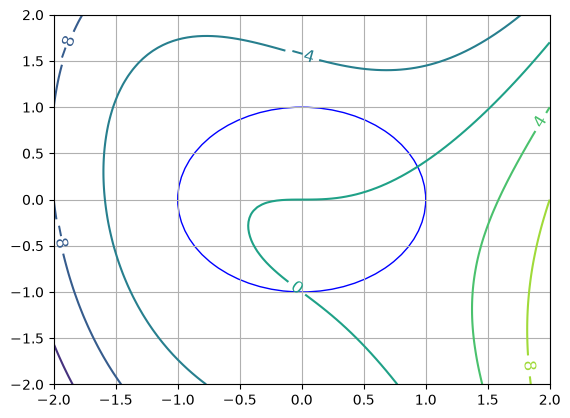

In [9]:
def visualize(xk=[]):
    n1 = 101
    n2 = 101
    x1eval = np.linspace(-2, 2, n1)
    x2eval = np.linspace(-2, 2, n2)

    X, Y = np.meshgrid(x1eval, x2eval)

    Z = np.zeros([n2, n1])

    for i in range(0, n1):
        for j in range(0, n2):
            Z[j, i] = my_f3((X[j, i], Y[j, i]))

    fig, ax = plt.subplots(1, 1)
    CS = ax.contour(X, Y, Z)
    ax.clabel(CS, inline=1, fontsize=12)

    # Add grid
    plt.grid()

    # Add unit circle
    circ = plt.Circle((0, 0), radius=1, edgecolor="b", facecolor="None")
    ax.add_patch(circ)

    # Plot iteration history
    if len(xk) > 0:
        for i in range(0, len(xk)):
            if i == len(xk) - 1:
                c = "red"
            else:
                c = "black"
            plt.scatter((xk[i][0]), (xk[i][1]), marker="o", color=c)

    plt.xlim([-2, 2])
    plt.ylim([-2, 2])


visualize()

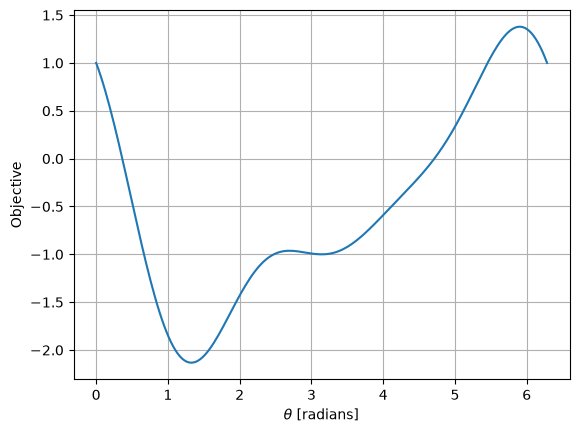

In [10]:
nt = 200
theta = np.linspace(0, 2 * np.pi, nt)
obj = np.zeros(nt)


for i in range(0, nt):
    x_ = np.cos(theta[i])
    y_ = np.sin(theta[i])

    obj[i] = my_f3((x_, y_))


plt.figure()
plt.plot(theta, obj)
plt.xlabel("$\\theta$ [radians]")
plt.ylabel("Objective")
plt.grid()

### Starting Point Near Global Min ($\theta_0 = 1.0$)

Iter. 	f(x) 		||h(x)|| 	||grad_L(x)|| 	||dx|| 		||dv||
0   	-6.9105e-01 	0.0000e+00 	3.7501e+00 	 1.1171e+00 	 1.1455e+00
1   	-4.0104e+00 	1.2480e+00 	2.1729e+00 	 4.2318e-01 	 3.9673e-01
2   	-2.4216e+00 	1.7908e-01 	3.3576e-01 	 8.3650e-02 	 1.0203e-01
3   	-2.1438e+00 	6.9974e-03 	1.7090e-02 	 3.5301e-03 	 6.5771e-03
4   	-2.1324e+00 	1.2462e-05 	4.7182e-05 	 6.3567e-06 	 2.0148e-05
5   	-2.1323e+00 	4.0409e-11 	1.6165e-09 	 1.6240e-10 	 6.8425e-10

x* = [0.24215301 0.97023807]

v* = [1.64012795]

theta* = 1.3262120356851443 = 1.3262120356851441


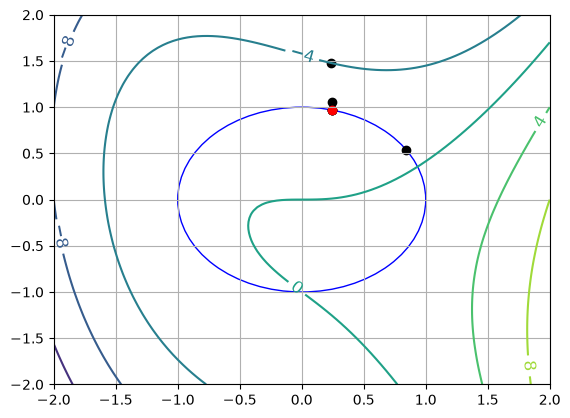

In [11]:
theta0 = 1.0
x0 = np.array((np.sin(theta0), np.cos(theta0)))

## Run Algorithm 5.1 on test problem
results = alg51(x0, my_f3, my_h3)

## Display results
xstar = results[0][-1]
print("\nx* =", xstar)

## Display results
vstar = results[1][-1]
print("\nv* =", vstar)

## Convert into theta
print("\ntheta* =", np.arccos(xstar[0]), "=", np.arcsin(xstar[1]))

## Visualize
visualize(results[0])

### Starting Point Near Local Min ($\theta_0 = \pi$)

Iter. 	f(x) 		||h(x)|| 	||grad_L(x)|| 	||dx|| 		||dv||
0   	 2.2204e-16 	0.0000e+00 	1.4142e+00 	 5.0002e-01 	 2.4998e-01
1   	-6.2504e-01 	2.5002e-01 	1.0000e+00 	 1.5692e+00 	 5.7495e-01
2   	 1.4170e+00 	2.4623e+00 	4.6905e+00 	 8.7011e-01 	 3.2837e-01
3   	-2.5307e-01 	7.5710e-01 	1.5057e+00 	 7.9522e-01 	 2.7967e-01
4   	-1.0865e+00 	6.3237e-01 	1.3372e+00 	 8.5438e-01 	 2.8373e-01
5   	-1.3500e-01 	7.2997e-01 	1.6074e+00 	 7.2933e-01 	 2.4682e-01
6   	-8.5827e-01 	5.3192e-01 	1.1567e+00 	 1.2157e+00 	 4.1616e-01
7   	 6.2238e-01 	1.4778e+00 	3.1877e+00 	 7.4241e-01 	 2.5368e-01
8   	-3.7570e-01 	5.5117e-01 	1.1904e+00 	 1.0968e+00 	 3.7414e-01
9   	-2.4718e+00 	1.2030e+00 	2.6015e+00 	 7.1059e-01 	 2.4215e-01
10   	-7.4660e-01 	5.0493e-01 	1.0928e+00 	 1.8715e+00 	 6.3841e-01
11   	 3.8801e+00 	3.5027e+00 	7.5746e+00 	 1.0086e+00 	 3.4412e-01
12   	 1.2452e-01 	1.0172e+00 	2.1996e+00 	 6.9856e-01 	 2.3812e-01
13   	-5.6901e-01 	4.8798e-01 	1.0555e+00 	 8.3344e+00 	 2.8422e+00
14 

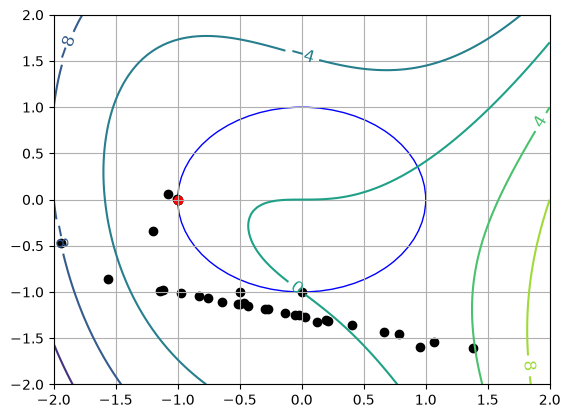

In [12]:
theta0 = np.pi
x0 = np.array((np.sin(theta0), np.cos(theta0)))

## Run Algorithm 5.1 on test problem
results = alg51(x0, my_f3, my_h3)

## Display results
xstar = results[0][-1]
print("\nx* =", xstar)

## Display results
vstar = results[1][-1]
print("\nv* =", vstar)

## Convert into theta
print("\ntheta* =", np.arccos(xstar[0]), "(using arccos)")
print("\ntheta* =", np.arcsin(xstar[1]), "(using arcsin)")

## Visualize
visualize(results[0])

### Starting Point Near Global Max ($\theta_0 = 5.5$)

Iter. 	f(x) 		||h(x)|| 	||grad_L(x)|| 	||dx|| 		||dv||
0   	-1.0621e+00 	0.0000e+00 	6.9215e-01 	 3.0715e-01 	 5.4165e-02
1   	-1.0667e+00 	9.4343e-02 	1.2087e-01 	 5.8627e-02 	 5.2399e-02
2   	-9.6641e-01 	3.4371e-03 	6.8330e-03 	 5.8240e-03 	 6.8759e-03
3   	-9.6261e-01 	3.3919e-05 	7.9250e-05 	 9.2697e-05 	 8.6676e-05
4   	-9.6258e-01 	8.5927e-09 	2.2890e-08 	 2.5143e-08 	 2.4938e-08

x* = [-0.90194813  0.43184437]

v* = [1.11352685]

theta* = 2.695055996995358 (using arccos)

theta* = 0.44653665659443614 (using arcsin)


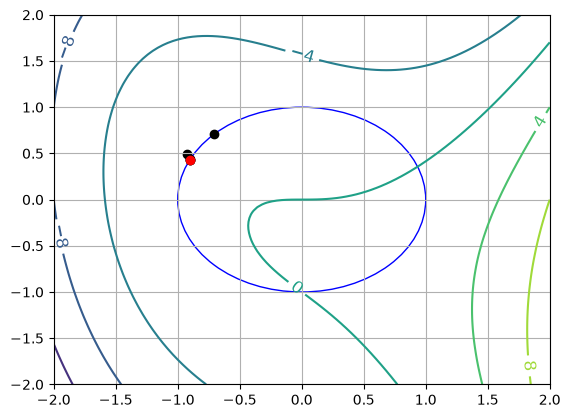

In [13]:
theta0 = 5.5
x0 = np.array((np.sin(theta0), np.cos(theta0)))

## Run Algorithm 5.1 on test problem
results = alg51(x0, my_f3, my_h3)

## Display results
xstar = results[0][-1]
print("\nx* =", xstar)

## Display results
vstar = results[1][-1]
print("\nv* =", vstar)

## Convert into theta
print("\ntheta* =", np.arccos(xstar[0]), "(using arccos)")
print("\ntheta* =", np.arcsin(xstar[1]), "(using arcsin)")

## Visualize
visualize(results[0])